In [51]:
import pandas

In [52]:
# Importing all cleaned datasets
df_usagers = pandas.read_csv("df_usagers_clean.csv")
df_caract = pandas.read_csv("df_caract_clean.csv")
df_lieux = pandas.read_csv("df_lieux_clean.csv")
df_vehicules = pandas.read_csv("df_vehicules_clean.csv")

In [53]:
df_main = df_usagers.merge(df_vehicules, on = ['Num_Acc', 'id_vehicule'], how='left')
df_main = df_main.merge(df_caract, on = ['Num_Acc'], how = 'left')
df_main = df_main.merge(df_lieux, on = ['Num_Acc'], how = 'left')

In [54]:
df_main.dropna(inplace = True)

In [70]:
df_main.to_csv("df_clean.csv", index=False)

In [55]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

num_features = ['day_sin', 'day_cos', 'hour_sin', 'hour_cos']
cat_features = ['ceinture', 'catu', 'aucun', 'place', 'age_group', 'sexe', 'gants', 'casque', 'autre'] + ['lum', 'agg', 'int', 'atm', 'col', 'geo_cluster'] + ['circ', 'catr', 'prof', 'vma', 'situ', 'infra', 'surf', 'nbv', 'plan'] + ['catv', 'obs', 'obsm', 'choc', 'manv', 'motor'] 
features = num_features + cat_features
target = "grav_bin"

In [56]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features)
    ]
)

preprocessor_cat_only = ColumnTransformer(
    transformers=[
        ("cat", "passthrough", cat_features)
    ],
    remainder="drop"
)

In [76]:
from sklearn.model_selection import train_test_split
from imblearn.under_sampling import RandomUnderSampler

X = df_main[features]
y = df_main[target]

rus = RandomUnderSampler()
X_resampled, y_resampled = rus.fit_resample(X, y)

X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled,
    test_size=0.2,
    random_state=42
)

# X_train, X_test, y_train, y_test = train_test_split(
#     X, y,
#     test_size=0.2,
#     random_state=42,
#     stratify=y
# )

In [77]:
from sklearn.naive_bayes import CategoricalNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier

models = {
    "Categorical NB": CategoricalNB(),
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Decision Tree": DecisionTreeClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
}

pipelines = {}

for name, model in models.items():
    if name == "Categorical NB":
        prep = preprocessor_cat_only
    else:
        prep = preprocessor

    pipelines[name] = Pipeline([
        ("preprocessing", prep),
        ("model", model)
    ])

for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)

In [78]:
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

for name, pipe in pipelines.items():

    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:,1]

    print("\n", name)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("ROC AUC:", roc_auc_score(y_test, y_proba))
    print(classification_report(y_test, y_pred))


 Categorical NB
Accuracy: 0.7561977038334307
ROC AUC: 0.8326803354100657
              precision    recall  f1-score   support

           0       0.76      0.75      0.75     25664
           1       0.75      0.76      0.76     25726

    accuracy                           0.76     51390
   macro avg       0.76      0.76      0.76     51390
weighted avg       0.76      0.76      0.76     51390


 Logistic Regression
Accuracy: 0.7795680093403385
ROC AUC: 0.8590715377616073
              precision    recall  f1-score   support

           0       0.79      0.75      0.77     25664
           1       0.77      0.81      0.79     25726

    accuracy                           0.78     51390
   macro avg       0.78      0.78      0.78     51390
weighted avg       0.78      0.78      0.78     51390


 Decision Tree
Accuracy: 0.7303561004086399
ROC AUC: 0.7304181935338421
              precision    recall  f1-score   support

           0       0.73      0.73      0.73     25664
           

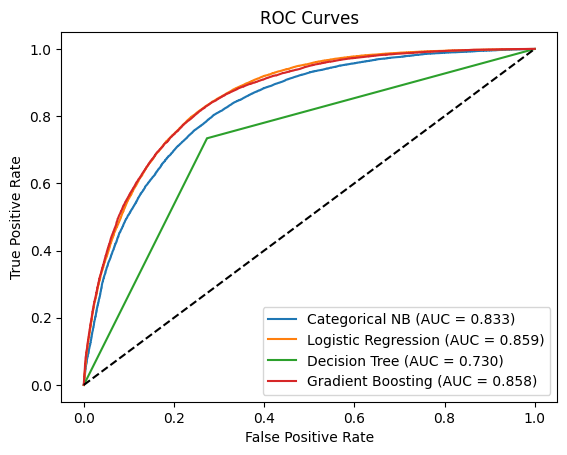

In [79]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure()

for name, pipe in pipelines.items():

    y_proba = pipe.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_score = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.3f})")

plt.plot([0,1],[0,1],"k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()

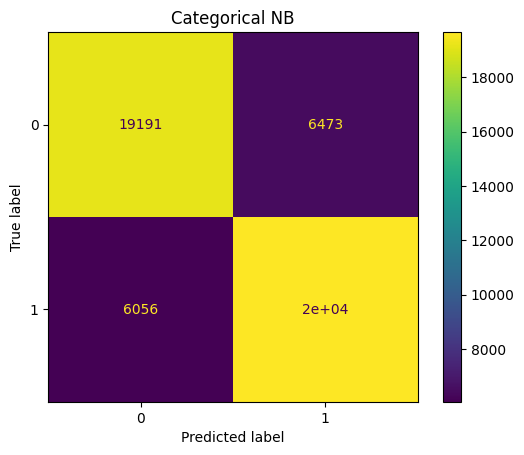

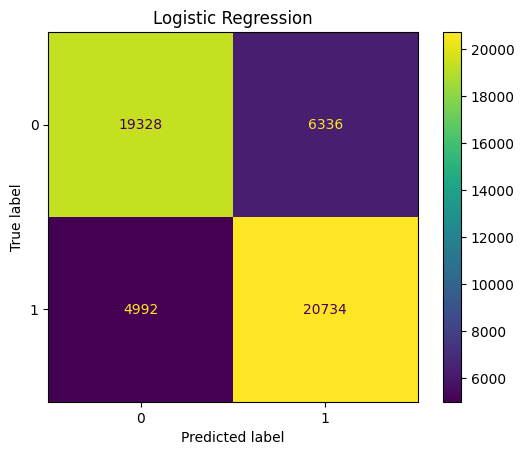

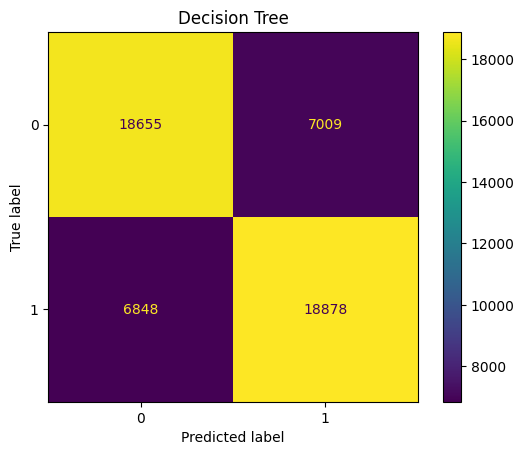

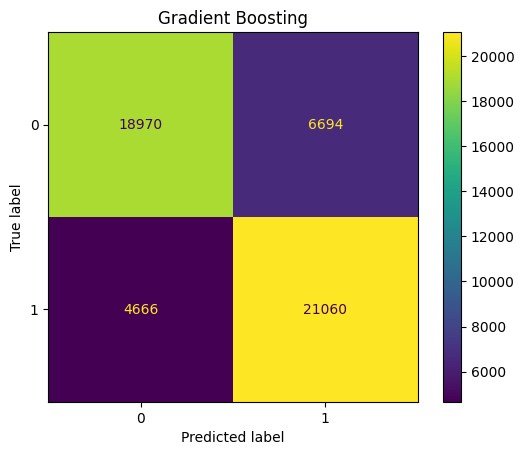

In [80]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

for name, model in pipelines.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(name)
    plt.show()